In [2]:
import pandas as pd

df = pd.read_csv("train.csv")

print(df.shape)
print(df.head())
print(df.columns.tolist())

(159571, 8)
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  
['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

LABELS = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

DATA_PATH = Path("train.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (159571, 8)


In [4]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [6]:
df.dtypes

,0
id,object
comment_text,object
toxic,int64
severe_toxic,int64
obscene,int64
threat,int64
insult,int64
identity_hate,int64


In [7]:
df.isnull().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [8]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df[LABELS].sum().sort_values(ascending=False)

,0
toxic,15294
obscene,8449
insult,7877
severe_toxic,1595
identity_hate,1405
threat,478


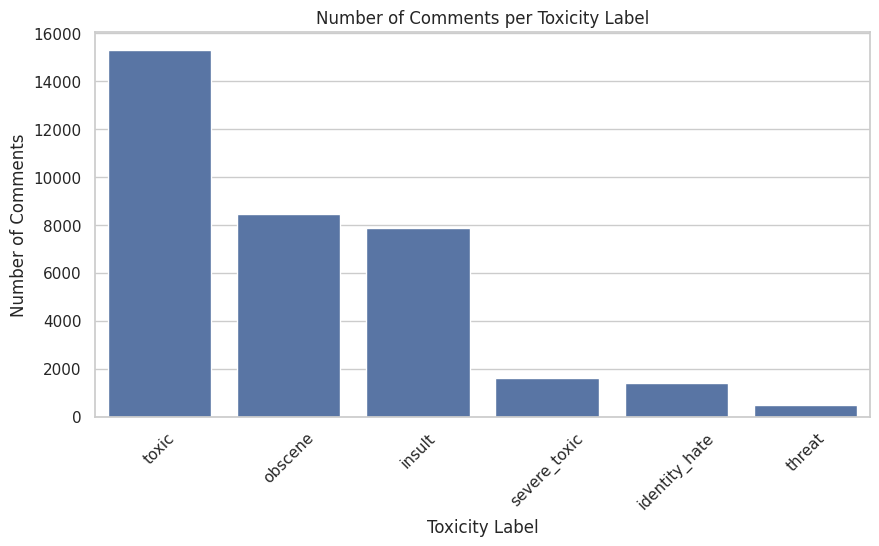

In [10]:
label_counts = df[LABELS].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=label_counts.index,
    y=label_counts.values
)

plt.title("Number of Comments per Toxicity Label")
plt.xlabel("Toxicity Label")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)

plt.show()

In [11]:
df["char_length"] = df["comment_text"].fillna("").str.len()

In [12]:
df["word_count"] = (
    df["comment_text"]
    .fillna("")
    .str.split()
    .str.len()
)

In [13]:
df[["char_length", "word_count"]].describe()

,char_length,word_count
count,159571.000000,159571.000000
mean,394.073221,67.273527
std,590.720282,99.230702
min,6.000000,1.000000
25%,96.000000,17.000000
50%,205.000000,36.000000
75%,435.000000,75.000000
max,5000.000000,1411.000000


In [14]:
print("Median characters:", df["char_length"].median())
print("Median words:", df["word_count"].median())

Median characters: 205.0
Median words: 36.0


In [15]:
print(
    "95th percentile characters:",
    df["char_length"].quantile(0.95)
)

print(
    "95th percentile words:",
    df["word_count"].quantile(0.95)
)

95th percentile characters: 1355.0
95th percentile words: 230.0


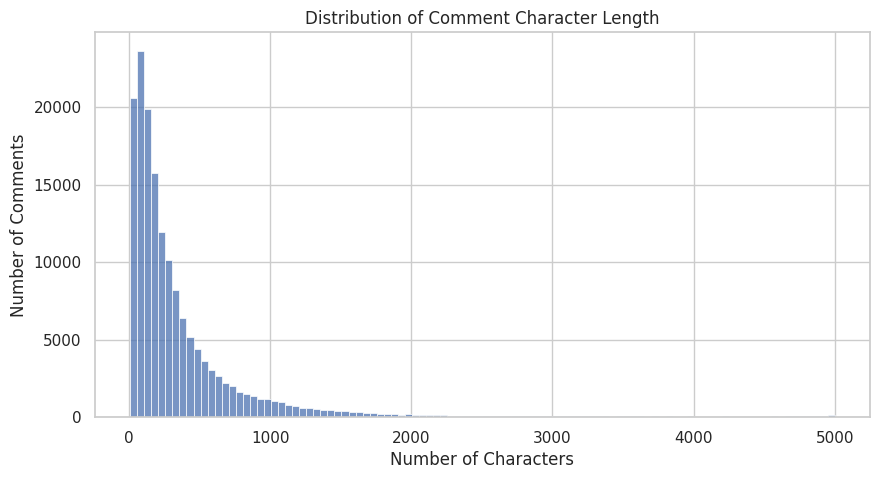

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["char_length"],
    bins=100
)

plt.title("Distribution of Comment Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Comments")

plt.show()

(0.0, 3444.0)

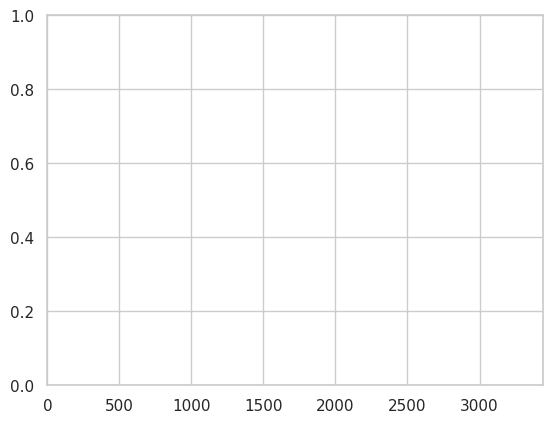

In [17]:
plt.xlim(0, df["char_length"].quantile(0.99))

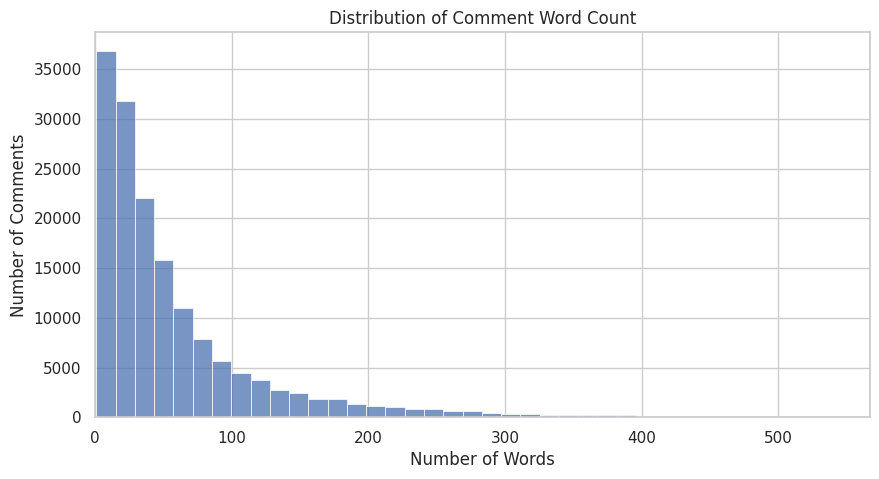

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["word_count"],
    bins=100
)

plt.title("Distribution of Comment Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Number of Comments")

plt.xlim(0, df["word_count"].quantile(0.99))

plt.show()

In [19]:
over_128 = (df["word_count"] > 128).sum()

percentage_over_128 = (
    over_128 / len(df) * 100
)

print("Comments over 128 words:", over_128)
print(f"Percentage over 128 words: {percentage_over_128:.2f}%")

Comments over 128 words: 20212
Percentage over 128 words: 12.67%


In [20]:
co_occurrence = df[LABELS].T.dot(df[LABELS])

print(co_occurrence)

               toxic  severe_toxic  obscene  threat  insult  identity_hate
toxic          15294          1595     7926     449    7344           1302
severe_toxic    1595          1595     1517     112    1371            313
obscene         7926          1517     8449     301    6155           1032
threat           449           112      301     478     307             98
insult          7344          1371     6155     307    7877           1160
identity_hate   1302           313     1032      98    1160           1405


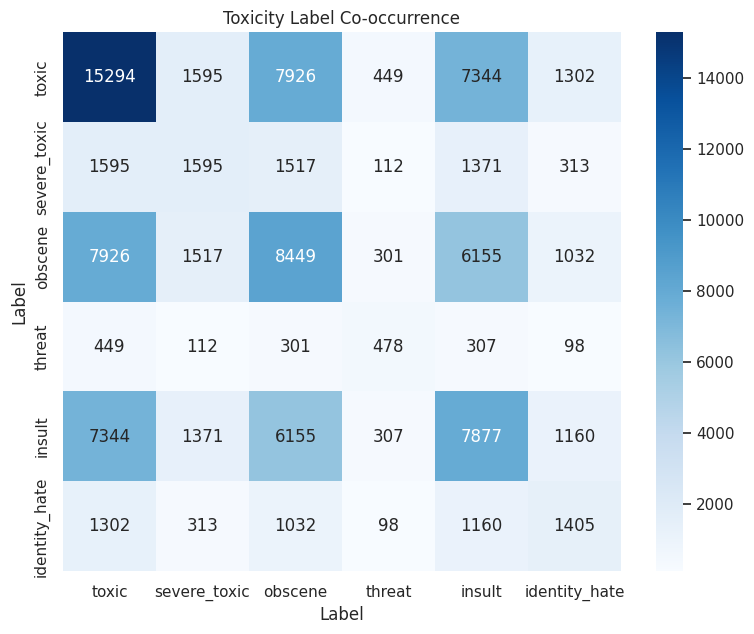

In [21]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    co_occurrence,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Toxicity Label Co-occurrence")
plt.xlabel("Label")
plt.ylabel("Label")

plt.show()

In [22]:
duplicate_count = df["comment_text"].duplicated().sum()

print("Duplicate comments:", duplicate_count)

Duplicate comments: 0


In [23]:
duplicate_percentage = (
    duplicate_count / len(df) * 100
)

print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate percentage: 0.00%


In [24]:
duplicates = df[
    df["comment_text"].duplicated(keep=False)
].sort_values("comment_text")

duplicates.head(20)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,char_length,word_count


In [25]:
duplicate_groups = (
    df[df["comment_text"].duplicated(keep=False)]
    .groupby("comment_text")[LABELS]
    .nunique()
)

conflicting_duplicates = duplicate_groups[
    duplicate_groups.max(axis=1) > 1
]

print(
    "Duplicate comments with conflicting labels:",
    len(conflicting_duplicates)
)

Duplicate comments with conflicting labels: 0


In [26]:
for label in LABELS:
    print("\n" + "=" * 60)
    print(label.upper())
    print("=" * 60)

    examples = df.loc[
        df[label] == 1,
        "comment_text"
    ].dropna().head(5)

    for i, comment in enumerate(examples, 1):
        print(f"{i}. {comment}")


TOXIC
1. COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK
2. Hey... what is it..
@ | talk .
What is it... an exclusive group of some WP TALIBANS...who are good at destroying, self-appointed purist who GANG UP any one who asks them questions abt their ANTI-SOCIAL and DESTRUCTIVE (non)-contribution at WP?

Ask Sityush to clean up his behavior than issue me nonsensical warnings...
3. Bye! 

Don't look, come or think of comming back! Tosser.
4. You are gay or antisemmitian? 

Archangel WHite Tiger

Meow! Greetingshhh!

Uh, there are two ways, why you do erased my comment about WW2, that holocaust was brutally slaying of Jews and not gays/Gypsys/Slavs/anyone...

1 - If you are anti-semitian, than shave your head bald and go to the skinhead meetings!

2 - If you doubt words of the Bible, that homosexuality is a deadly sin, make a pentagram tatoo on your forehead go to the satanistic masses with your gay pals!

3 - First and last warning, you fucking gay - I won't appreciate if any more nazi shw

In [27]:
eda_summary = {
    "rows": len(df),
    "columns": len(df.columns),
    "duplicate_comments": int(duplicate_count),
    "duplicate_percentage": float(duplicate_percentage),
    "median_char_length": float(df["char_length"].median()),
    "median_word_count": float(df["word_count"].median()),
    "95th_percentile_word_count": float(
        df["word_count"].quantile(0.95)
    ),
    "comments_over_128_words": int(over_128),
    "percentage_over_128_words": float(
        percentage_over_128
    )
}

eda_summary

{'rows': 159571,
 'columns': 10,
 'duplicate_comments': 0,
 'duplicate_percentage': 0.0,
 'median_char_length': 205.0,
 'median_word_count': 36.0,
 '95th_percentile_word_count': 230.0,
 'comments_over_128_words': 20212,
 'percentage_over_128_words': 12.666461951106402}

In [30]:
!pip install iterative-stratification

In [31]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit